In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [2]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [7]:
ticker = 'TTD'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="day", from_="2022-10-16", to="2025-02-04", limit=50000)):
    #if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
    price_performance['Open'].append(agg.open)
    price_performance['Close'].append(agg.close)
    price_performance['high'].append(agg.high)
    price_performance['low'].append(agg.low)
    price_performance['volume'].append(agg.volume)
    price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
    price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

577it [00:00, 2664.18it/s]


In [8]:
ticker_hist.iloc[-45:]['Close'].mean()

np.float64(125.14777777777778)

In [6]:
ticker_hist.iloc[-45:]['Close']

531    128.98
532    128.15
533    128.55
534    135.16
535    139.16
536    139.51
537    136.36
538    139.11
539    134.77
540    132.66
541    134.10
542    133.57
543    132.42
544    132.65
545    135.02
546    127.93
547    126.23
548    125.01
549    121.67
550    123.96
551    123.46
552    121.39
553    120.17
554    117.53
555    117.73
556    121.84
557    126.58
558    121.41
559    121.52
560    118.80
561    117.89
562    116.76
563    119.68
564    120.84
565    124.42
566    124.50
567    120.69
568    119.14
569    119.96
570    119.10
571    120.56
572    122.59
573    118.94
574    118.68
575    117.94
Name: Close, dtype: float64

In [21]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

times = pd.DataFrame(ticker_hist['Time'].unique())
times.columns = ['Time']
times['Time'] = times['Time'].sort_values().reset_index(drop = True)

ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}
ab_params['autocorr_slope'] = {}
ab_params['autocorr_intercept'] = {}

print('analyzing')

dates = ticker_hist['Date'].unique()

autocorrs = []
for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    ticker_hist_date = ticker_hist_date.ffill()

    ticker_hist_date['logReturns'] = ticker_hist_date['logOpen'].diff()
    ticker_hist_date['logReturns_shifted'] = ticker_hist_date['logReturns'].shift(-1)

    autocorr_calc = ticker_hist_date[['logReturns', 'logReturns_shifted']].dropna()

    lr = LinearRegression()

    lr.fit(
        autocorr_calc['logReturns'].values.reshape(-1, 1),
        autocorr_calc['logReturns_shifted'].values
    )

    idiosyncratic_returns = lr.predict(autocorr_calc['logReturns'].values.reshape(-1, 1))

    noise_returns = autocorr_calc['logReturns_shifted'] - idiosyncratic_returns

    a = np.median(noise_returns)
    b = np.sum(
            np.abs(noise_returns - a)
    ) / (len(noise_returns))

    ab_params['autocorr_slope'][date] = lr.coef_[0]
    ab_params['autocorr_intercept'][date] = lr.intercept_
    
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


552it [02:52,  3.19it/s]


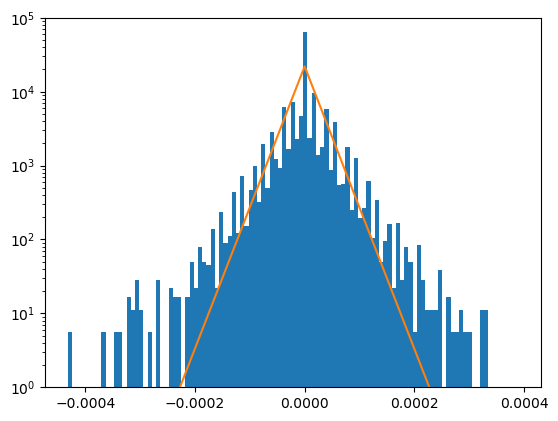

In [22]:
plt.hist(noise_returns, bins = 100, density = True)

plt.plot(
    np.arange(-0.0004, 0.0004, 0.00001),
    1 / (2*b) * np.exp(
        - np.abs(
            np.arange(-0.0004, 0.0004, 0.00001) - a
        )/(b)
    )
)
plt.ylim(10**0, 10**5)
plt.yscale('log')
plt.show()

In [23]:
ab_params_df = pd.DataFrame(ab_params)

In [24]:
ab_params_df

,a,b,autocorr_slope,autocorr_intercept
2022-10-17,-4.057316e-07,0.000055,0.039821,4.057316e-07
2022-10-18,7.682807e-07,0.000073,0.041388,-7.682807e-07
2022-10-19,-1.250215e-07,0.000066,0.046344,1.250215e-07
2022-10-20,7.157939e-08,0.000065,0.019579,-7.157939e-08
2022-10-21,-1.177104e-06,0.000079,0.010421,1.177104e-06
...,...,...,...,...
2024-12-19,5.284314e-07,0.000049,0.054642,-5.284314e-07
2024-12-20,-6.780655e-07,0.000046,0.039289,6.780655e-07
2024-12-23,-2.533190e-07,0.000034,0.025054,2.533190e-07
2024-12-24,-4.245466e-07,0.000015,-0.015442,4.245466e-07


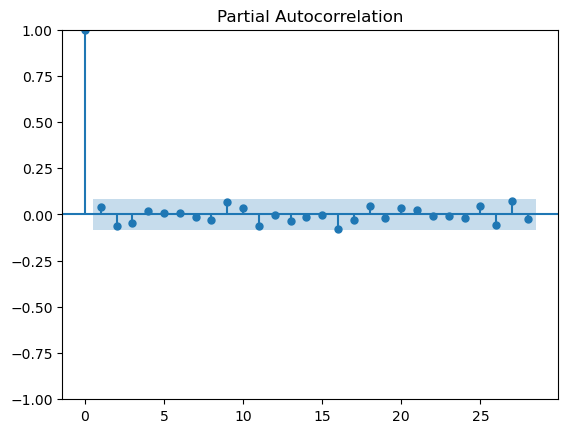

In [25]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

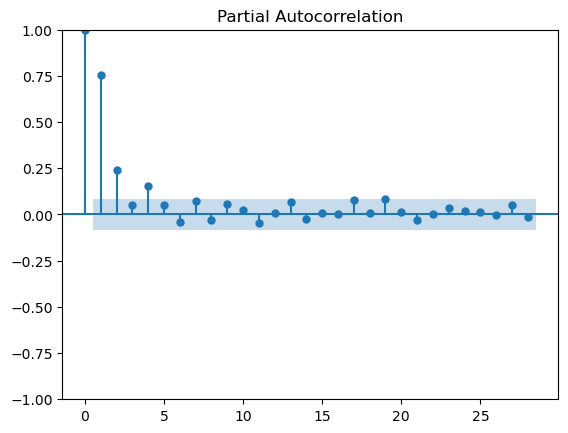

In [26]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

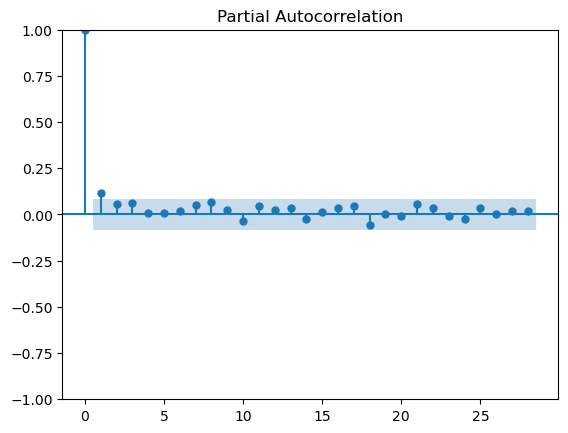

In [27]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['autocorr_slope']
)
plt.show()

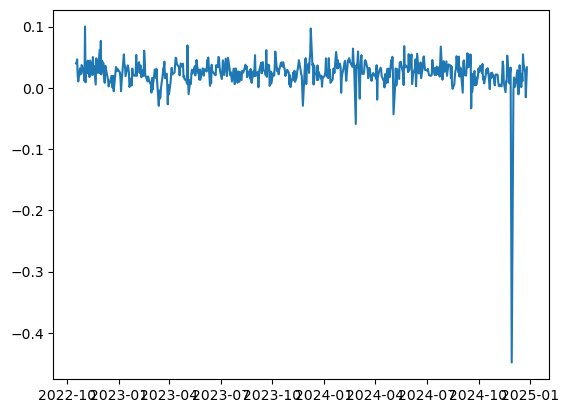

In [28]:
plt.plot(ab_params_df['autocorr_slope'])

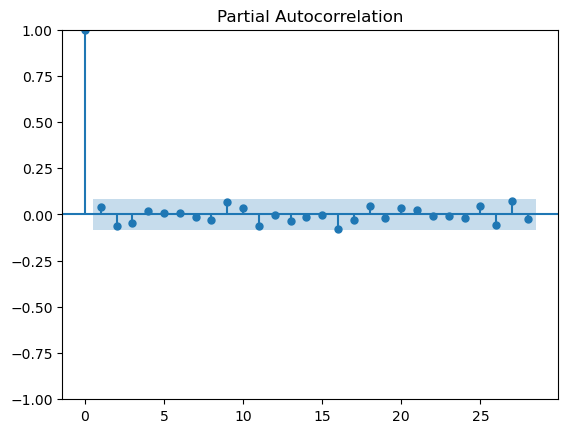

In [29]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['autocorr_intercept']
)
plt.show()

In [30]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['autocorr_slope'].iloc[:-1])

SignificanceResult(statistic=np.float64(0.009061426224686699), pvalue=np.float64(0.8319325180151037))

In [31]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['autocorr_slope'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.06283871856614975), pvalue=np.float64(0.14071219067889945))

In [32]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)
ab_params_df['shifted_autocorr_slope'] = ab_params_df['autocorr_slope'].shift(-1)
ab_params_df['shifted_autocorr_intercept'] = ab_params_df['autocorr_intercept'].shift(-1)

In [33]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_a_1']))

lr_autocorr_slope = LinearRegression()

lr_autocorr_slope.fit(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_slope'])
print(lr_autocorr_slope.score(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_slope']))

lr_autocorr_intercept = LinearRegression()

lr_autocorr_intercept.fit(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_intercept'])
print(lr_autocorr_intercept.score(ab_params_df.dropna()[['a', 'b', 'autocorr_slope', 'autocorr_intercept']], ab_params_df.dropna()['shifted_autocorr_intercept']))



0.5725401166184871
0.011073880121699742
0.0141894786026604
0.011073880121699742


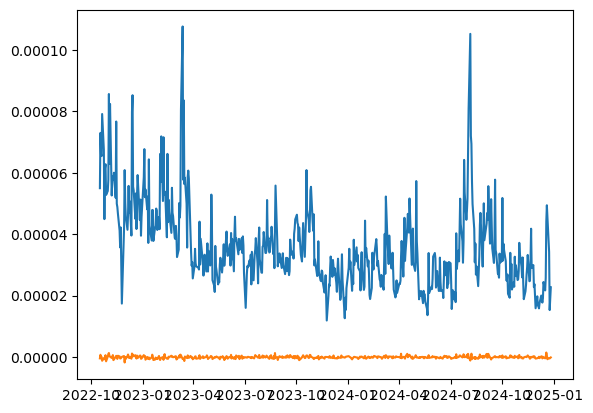

In [34]:
plt.plot(ab_params_df['b'])
plt.plot(ab_params_df['a'])

In [35]:
6.5*3600

23400.0

In [40]:
replicates = 10000
X0 = np.log ( (21768-140) / 21768)

T = np.arange(len(ticker_hist_date)).reshape(len(ticker_hist_date), 1).repeat(replicates, 1)

epsilon = np.random.laplace(
        loc=lr_a.predict(
            ab_params_df[
                ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
            ].dropna()
        )[-1], 
        scale=lr_b.predict(
            ab_params_df[
                ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
            ].dropna()
        )[-1],
        size=(len(ticker_hist_date), replicates)
    )

phi = lr_autocorr_slope.predict(
    ab_params_df[
        ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
    ].dropna()
)[-1]

delta = lr_autocorr_intercept.predict(
    ab_params_df[
        ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
    ].dropna()
)[-1]

In [41]:
lr_a.predict(
            ab_params_df[
                ['a', 'b', 'autocorr_slope', 'autocorr_intercept']
            ].dropna()
        )[-1]

np.float64(1.8595187948704885e-08)

In [42]:
possible_daily_returns = []

for r in tqdm(range(replicates)):
    possible = X0.copy()
    last_increment = X0.copy()
    for k in range(len(ticker_hist_date)):
        last_increment = phi * last_increment + delta + epsilon[k, r]
        possible += last_increment
    possible_daily_returns.append(possible)
        

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:15<00:00, 133.33it/s]


In [39]:
possible_daily_returns

[np.float64(-0.0026710252853728743),
 np.float64(-0.010302012008165468),
 np.float64(-0.013704987071176658),
 np.float64(-0.00965467541928556),
 np.float64(-0.009013068685957257),
 np.float64(-0.0036660373367587732),
 np.float64(-0.0031683832397709417),
 np.float64(0.00386141530397241),
 np.float64(-0.002805989176261213),
 np.float64(0.0006191218789166116),
 np.float64(-0.0021310702489260864),
 np.float64(-0.005672560836598322),
 np.float64(-0.010375752217488921),
 np.float64(-0.012353666632810255),
 np.float64(-0.004433918554826489),
 np.float64(0.009430669608360974),
 np.float64(-0.007663276898370849),
 np.float64(-0.001534177346120851),
 np.float64(-0.005881969524120902),
 np.float64(-0.009665995079763623),
 np.float64(-0.0032633526276478263),
 np.float64(-0.0061152459737325625),
 np.float64(-0.002101914790946589),
 np.float64(0.004387738694765863),
 np.float64(-0.007571808870978254),
 np.float64(-0.0032107915162824453),
 np.float64(-0.007274870772278428),
 np.float64(-0.00603814598

# declare spot ticker price

In [43]:
spot_spx_price = 21768

In [44]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_daily_returns))

In [45]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))

21623.731952921553
125.55304419610248


In [110]:
upper_call = 21720.
lower_call = 21710.
upper_put = 21320.
lower_put = 21310.

In [58]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

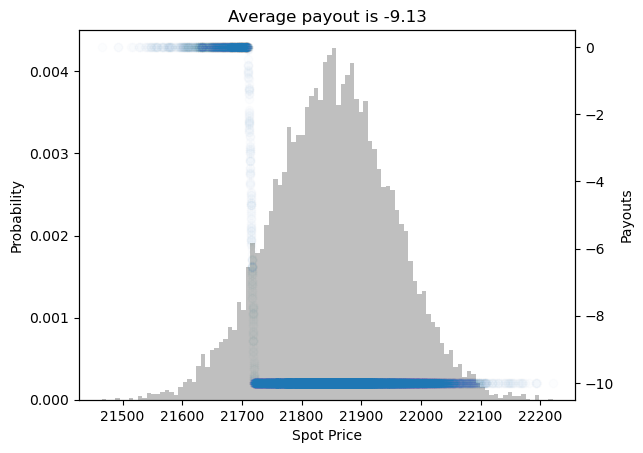

In [59]:
fig, axs = plt.subplots()

axs.hist(possible_final_prices, bins = 100, density = True, alpha=0.5, color = 'grey')
axs.set_ylabel('Probability')
axs.set_xlabel('Spot Price')
#axs.set_title('SPX Price Range, Intra-day, one second predictions')
axs_right = axs.twinx()
#plt.savefig('end_price_distro.pdf', bbox_inches = 'tight')
axs_right.scatter(possible_final_prices, payouts,  alpha=0.01)
axs_right.set_ylabel('Payouts')
mean_payout = np.round(np.mean(payouts), 2)
axs.set_title(f'Average payout is {mean_payout}')
plt.savefig('with_strategy.png', bbox_inches = 'tight')

plt.show()

# compute cost of trade and max loss

In [30]:
cost_of_trade = 2.10
max_loss = 10

In [31]:
p = (max_loss - cost_of_trade)/max_loss

In [32]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is 1.1102230246251565e-16


In [33]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.6880952380952381
